In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)
f = 1e9

# --- domínio ---
min_lambda = vp / f  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = 100
Ny = 50
dx = dy = 0.1 * min_lambda
dt_list = [0.5, 0.9, 0.98, 0.99, 1, 1.01, 1.1] / (vp * np.sqrt((1/dx**2) + (1/dy**2)))
# dt_list = [0.99] / (vp * np.sqrt((1/dx**2) + (1/dy**2)))
max_value_per_dt = []

for dt in dt_list:
    Nt = 500
    L = Nx * dx
    T = Nt * dt

    grid_x_Ez = np.linspace(0, L, Nx + 1)
    grid_y_Ez = np.linspace(0, L, Ny + 1)
    grid_t_Ez = np.linspace(0, T, Nt + 1)

    grid_x_Hx = np.linspace(0, L, Nx + 1)
    grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
    grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

    grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
    grid_y_Hy = np.linspace(0, L, Ny + 1)
    grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

    # --- campos ---
    Ez_curr = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
    Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
    Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

    # valores do tempo para salvar os snapshots e montar os heatmaps
    n_snapshots = np.linspace(5, Nt - 5, 6, dtype=int)
    Ez_snapshots = []

    # ponta de prova no centro
    probe = []
    cx, cy = Nx // 2, Ny // 2

    for n in range(Nt-1):
        # fonte onda planar
        source = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)
        source_senoidal = np.sin(2 * np.pi * f * n * dt)

        # aplica em todos os Y em X = 0 (left boundary plane wave)
        Ez_curr[0, :] = source_senoidal

        Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
            Ez_curr[:, 1:] - Ez_curr[:, :-1]
        )

        Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
            Ez_curr[1:, :] - Ez_curr[:-1, :]
        )

        Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
            (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
            (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
        )

        # PEC an extremidade direita
        Ez_next[-1, :] = 0

        # periodic boundary condition
        Ez_next[:, 0] = Ez_next[:, Ny]
        Hx_next[:, 0] = Hx_next[:, Ny - 1]

        # atualiza os campos para o próximo passo
        Ez_curr = Ez_next.copy()
        Hx_curr = Hx_next.copy()
        Hy_curr = Hy_next.copy()

        # salva na ponta de prova
        probe.append(Ez_curr[cx, cy])

        # salva para os snapshots
        if n in n_snapshots:
            Ez_snapshots.append(Ez_curr.copy())

    max_value_per_dt.append(np.max(probe))


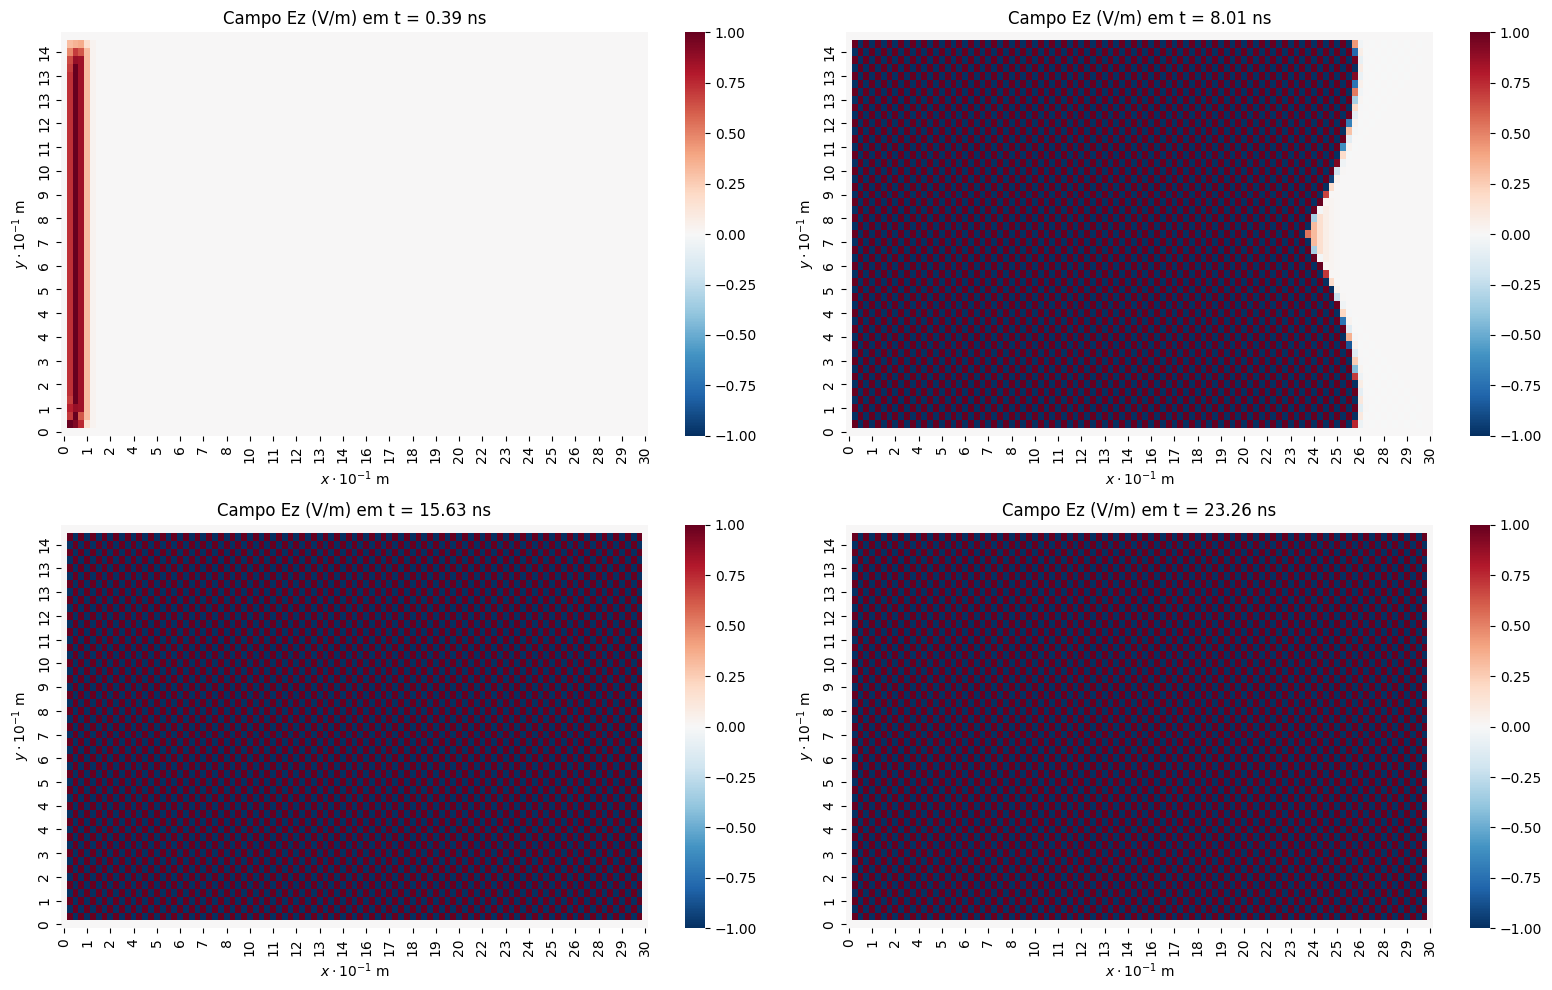

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i].T, ax=ax, annot=False, cmap='RdBu_r',vmin=-1, vmax=1, center=0)
    ax.set_xlabel(r"$x \cdot 10^{-1}$ m")
    ax.set_ylabel(r"$y \cdot 10^{-1}$ m")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 10:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 10:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [77]:
max_value_per_dt

[np.float64(1.1877994436950596),
 np.float64(1.256896740068978),
 np.float64(1.2505073747777342),
 np.float64(1.2498804334963738),
 np.float64(1.2503982513780767),
 np.float64(1.138525508483738e+54),
 np.float64(1.0165400091094856e+184)]